# Gate Function Visualization

Visualize the mapping from pre-activation to gate output for all gate types.

In [1]:
import matplotlib.pyplot as plt
import torch

# Import gate classes
from spd.models.components import (
    BoundedGateMLP,
    GateMLP,
    ScaledSigmoidGateMLP,
    SigmoidGateMLP,
    SwishSigmoidGateMLP,
    leaky_relu,
)

In [2]:
# Create gate instances (m=1 for simplicity, n_gate_hidden_neurons=16 for MLP gates)
gates = {
    "GateMLP (Leaky ReLU)": GateMLP(m=1, n_gate_hidden_neurons=16),
    "SigmoidGateMLP": SigmoidGateMLP(m=1, n_gate_hidden_neurons=16),
    "SwishSigmoidGateMLP": SwishSigmoidGateMLP(m=1, n_gate_hidden_neurons=16),
    "ScaledSigmoidGateMLP": ScaledSigmoidGateMLP(m=1, n_gate_hidden_neurons=16),
    "BoundedGateMLP": BoundedGateMLP(m=1, n_gate_hidden_neurons=16),
}


# Monkey patch _compute_pre_activation to return identity for visualization
def identity_pre_activation(self, x):
    return x


# Apply monkey patch to MLP gates
for gate_name, gate in gates.items():
    if hasattr(gate, "_compute_pre_activation"):
        gate._compute_pre_activation = identity_pre_activation.__get__(gate, gate.__class__)

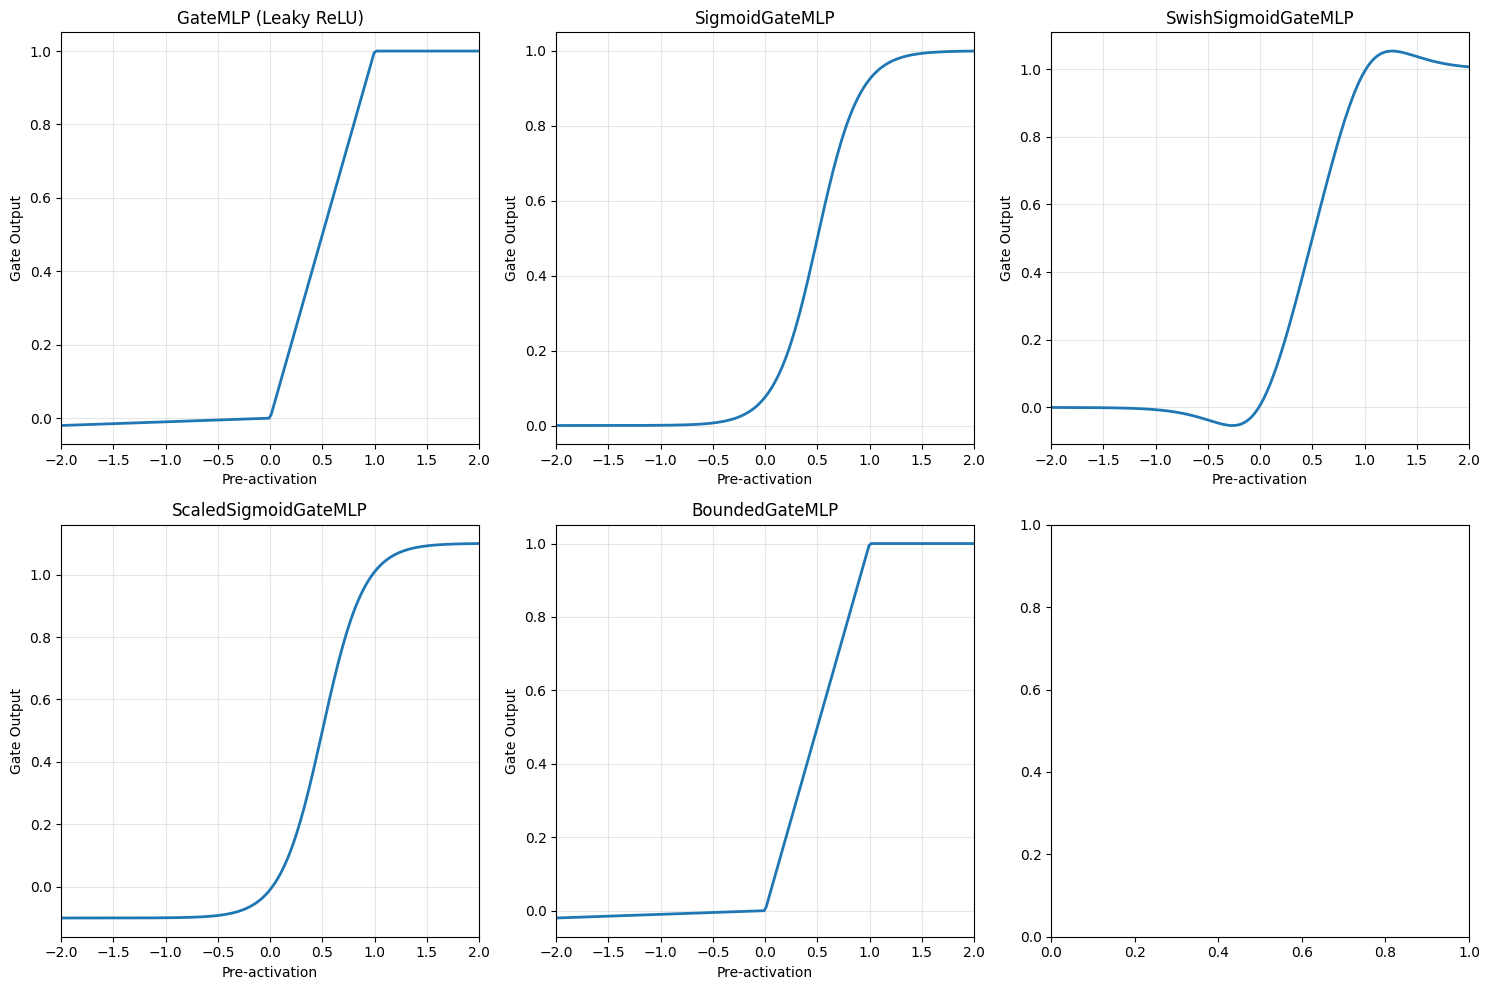

In [3]:
# Generate input range
x_range = torch.linspace(-2, 2, 200).unsqueeze(0)  # Shape: (1, 200)

# Plot all gates
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (gate_name, gate) in enumerate(gates.items()):
    with torch.no_grad():
        if gate_name == "Gate (Leaky ReLU)":
            # For simple Gate, manually apply the activation
            y = leaky_relu(torch.clamp(x_range, max=1))
        else:
            y = gate.forward(x_range)

    axes[i].plot(x_range.squeeze().numpy(), y.squeeze().numpy(), linewidth=2)
    axes[i].set_title(gate_name)
    axes[i].set_xlabel("Pre-activation")
    axes[i].set_ylabel("Gate Output")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-2, 2)

plt.tight_layout()
plt.show()

In [ ]:
# Print gate output ranges for reference
print("Gate output ranges:")
for gate_name, gate in gates.items():
    with torch.no_grad():
        if gate_name == "Gate (Leaky ReLU)":
            y = leaky_relu(torch.clamp(x_range, max=1))
        else:
            y = gate.forward(x_range)
    print(f"{gate_name}: [{y.min().item():.3f}, {y.max().item():.3f}]")